# Data Audit of Titanic Survival Data
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

In [3]:
sys.path.append(os.path.abspath('C:/Dev/Projects/EDA-Portfolio/Titanic-Survival-Dataset/src'))
os.listdir('C:/Dev/Projects/EDA-Portfolio/Titanic-Survival-Dataset/src')

['utils.py']

In [ ]:
df=pd.read_csv('Titanic-Survival-Dataset/Data/raw/train.csv')

In [21]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [22]:
df.shape

(891, 12)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [24]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [25]:
df['Survived'].describe()

count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64

In [26]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [27]:
df.isnull().sum().sum()

np.int64(866)

In [28]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [38]:
df.duplicated().sum()


np.int64(0)

In [29]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

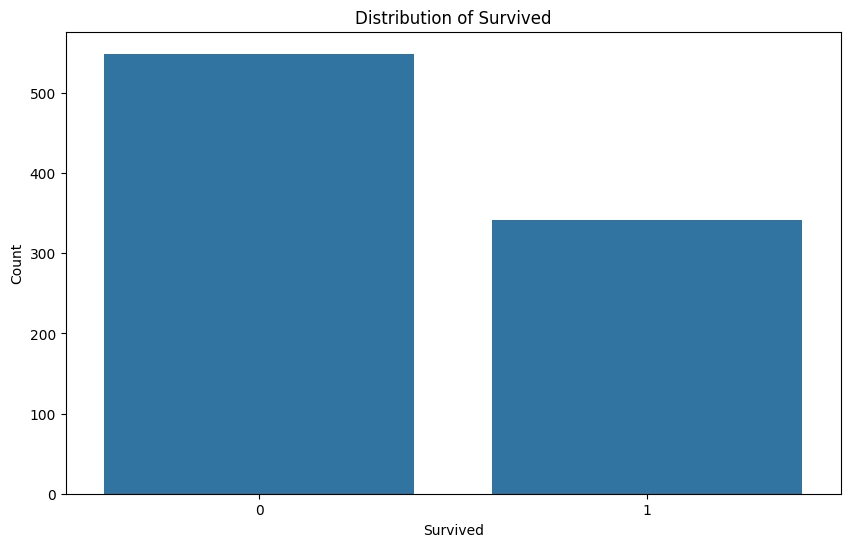

In [32]:
plt.figure(figsize=(10,6))
sns.countplot(x='Survived', data=df)
plt.title('Distribution of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

In [33]:
print("Percentage of missing values in each column:")
df.isnull().sum()/len(df)*100

Percentage of missing values in each column:


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [40]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object','string']).columns.tolist()
num_cols.remove('Pclass')
cat_cols.append('Pclass')
print("Numerical columns:",len(num_cols),",", num_cols)
print("Categorical columns:", len(cat_cols), ",", cat_cols)

Numerical columns: 6 , ['PassengerId', 'Survived', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: 6 , ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'Pclass']


In [43]:
from utils import data_audit
audit=data_audit(df)
audit.head(20)

,Data Type,Missing Values,Unique Values,Percentage Missing,zero variance columns,Duplicate rows
PassengerId,int64,0,891,0.000000,False,0
Survived,int64,0,2,0.000000,False,0
Pclass,int64,0,3,0.000000,False,0
Name,str,0,891,0.000000,False,0
Sex,str,0,2,0.000000,False,0
Age,float64,177,88,19.865320,False,0
SibSp,int64,0,7,0.000000,False,0
Parch,int64,0,7,0.000000,False,0
Ticket,str,0,681,0.000000,False,0
Fare,float64,0,248,0.000000,False,0


In [44]:
audit.to_csv('Titanic-Survival-Dataset/Data/processed/data_audit.csv', index=False)

## Data Audit Summary

- The dataset contains **891 passenger records and 12 features**.
- The target variable is **`Survived`**, indicating whether a passenger survived the Titanic disaster.
- The dataset includes both **numerical features** (Age, Fare, SibSp, Parch) and **categorical features** (Sex, Embarked, Cabin, Ticket).
- Missing values are mainly present in **Age, Cabin, and Embarked** columns.
- **Cabin** has a large number of missing values, while **Age** has a moderate number of missing entries.
- Some columns such as **PassengerId, Name, and Ticket** act as identifiers or text features and may require transformation or removal during feature engineering.
- The dataset contains both survived and non-survived passengers, confirming it as a **binary classification problem**.
- The insights from this audit will guide the **data cleaning and exploratory data analysis stages**.